# Housing Pricing Decision Support System 

This project simulates a data-driven pricing decision support system to assist real estate professionals in evaluating property value more accurately.
 
**Goal：**

- Build a regression-based housing price prediction model.
 
- Identify key structural and quality-related drivers of property value.
 
- Evaluate model performance using appropriate validation techniques.
 
- Translate analytical findings into actionable pricing insights.

## Contents

1. load data
2. data overview
3. missing value check
4. target distribution
5. log transformation
6. correlation analysis
7. feature engineering
8. train_test_split
9. linear regression
 10. RMSE

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "train.csv"
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df= pd.read_csv(DATA_PATH)

df.shape

(1460, 81)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 82 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [11]:
num_cols=df.select_dtypes(include=['int64','float64']).columns
cat_cols=df.select_dtypes(include=['object']).columns

print("Numerical features:",len(num_cols))
print("Categorical features",len(cat_cols))

Numerical features: 39
Categorical features 43


In [3]:
df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Saved: True
../outputs/figures/price_distribution.png


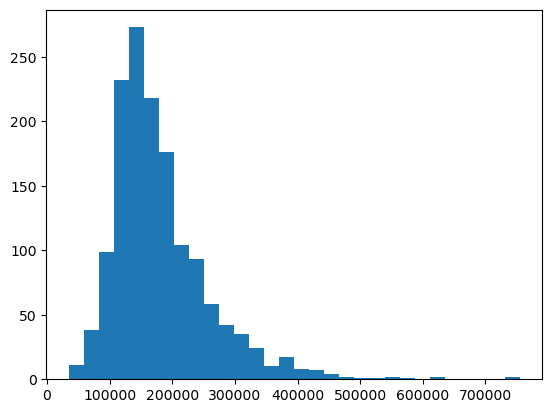

In [14]:
plt.hist(df['SalePrice'],bins=30)
plt.savefig(FIG_DIR / "price_distribution.png", dpi=300)
out = FIG_DIR / "price_distribution.png"
print("Saved:", out.exists())
print(out)

plt.show()

The target variable SalePrice exhibits a clear right-skewed distribution.
The mean price is higher than the median, indicating the presence of high-value outliers.
This skewness may affect linear regression assumptions and suggests that transformation(e.g., log transformation) could improve model stability.


In [10]:
missing=df.isnull().sum().sort_values(ascending=False)

missing_ratio=(df.isnull().sum()/len(df)).sort_values(ascending=False)

high_missing=missing_ratio[missing_ratio>0.5]
mid_missing=missing_ratio[(missing_ratio<=0.5)&(missing_ratio>0.1)]
low_missing = missing_ratio[missing_ratio <= 0.1]

print("High Missing:",len(high_missing))

print("Mid Missing:",len(mid_missing))

print("Low Missing:",len(low_missing))


High Missing: 5
Mid Missing: 2
Low Missing: 75


Missing values exhibit a structured pattern rather than random data loss.
High-missing variables such PoolQC and Alley likely indicate absence of the corresponding facility rather than incomplete data.
Therefore, these variables will be retained and treated as meaningful categorical information during preprocessing.
Moderate-missing variables such as LotFrontage may require targeted imputation strategies.

In [6]:
df.duplicated().sum()

np.int64(0)

Saved: True
../outputs/figures/original_log_saleprice.png


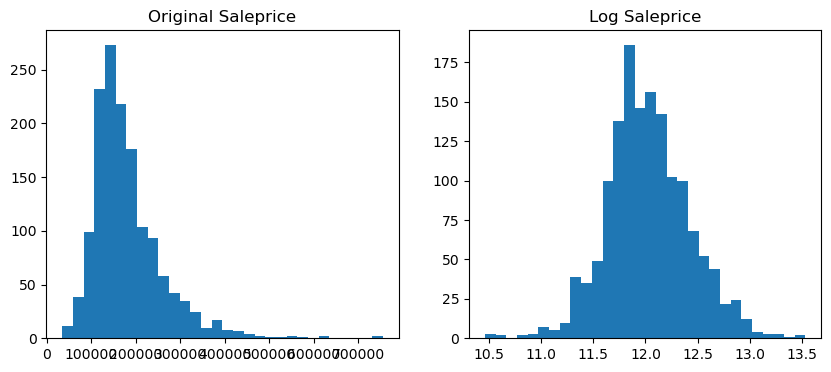

In [15]:
df['LogSalePrice']=np.log(df['SalePrice'])
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(df['SalePrice'],bins=30)
plt.title("Original Saleprice")

plt.subplot(1,2,2)
plt.hist(df['LogSalePrice'],bins=30)
plt.title("Log Saleprice")
plt.savefig(FIG_DIR / "original_log_saleprice.png", dpi=300)

out = FIG_DIR / "original_log_saleprice.png"
print("Saved:", out.exists())
print(out)


plt.show()

The original SalePrice distribution is highly right-skewed.
After applying log transformation, the distribution becomes more symmetric.
Therefore, LogSalePrice will be used for subsequent modeling.


In [12]:
corr_log = df[num_cols].corr()['LogSalePrice'].sort_values(ascending=False)
corr_log.head(10)

LogSalePrice    1.000000
SalePrice       0.948374
OverallQual     0.817184
GrLivArea       0.700927
GarageCars      0.680625
GarageArea      0.650888
TotalBsmtSF     0.612134
1stFlrSF        0.596981
FullBath        0.594771
YearBuilt       0.586570
Name: LogSalePrice, dtype: float64

The strongest price drivers include overall construction quality,living area size,garage capacity and basement area. These results align with typical real estate valuation logic, where structural quality and usable space are primary determinants of property value.

In [16]:
df[['GrLivArea','1stFlrSF']].corr()

,GrLivArea,1stFlrSF
GrLivArea,1.000000,0.566024
1stFlrSF,0.566024,1.000000


Although GrLivArea includes 1stFlrSF,the correlation between them is moderate rather than extremely high.
This suggests variation in second-floor across properties, reducing perfect linear dependency.

Saved: True
../outputs/figures/OverallQual_saleprice.png


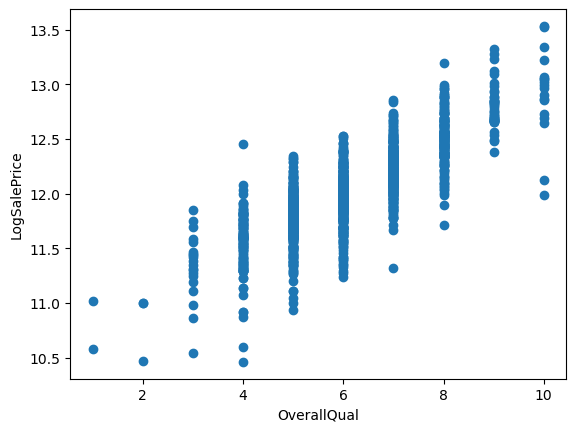

In [18]:
plt.scatter(df['OverallQual'], df['LogSalePrice'])
plt.xlabel('OverallQual')
plt.ylabel('LogSalePrice')
plt.savefig(FIG_DIR / "OverallQual_saleprice.png", dpi=300)

out = FIG_DIR / "OverallQual_saleprice.png"
print("Saved:", out.exists())
print(out)

plt.show()

The scatter plot shows a clear positive linear relationship between OverallQual and LogSalePrice.
As construction quality increases, housing prices tend to increase accordingly.
No extreme outliers are observed, suggesting a relatively stable linear trend.

Saved: True
../outputs/figures/GrLivArea_saleprice.png


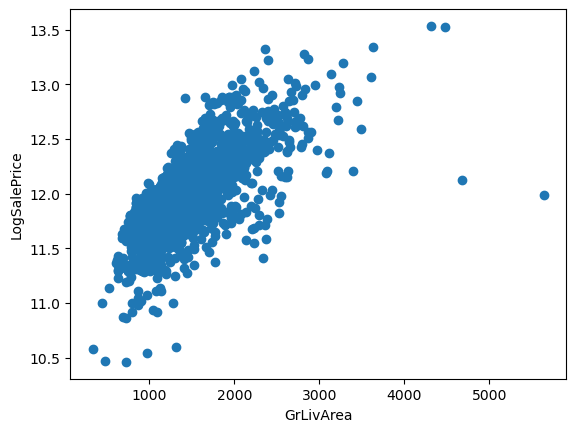

In [20]:
plt.scatter(df['GrLivArea'], df['LogSalePrice'])
plt.xlabel('GrLivArea')
plt.ylabel('LogSalePrice')
plt.savefig(FIG_DIR / "GrLivArea_saleprice.png", dpi=300)

out = FIG_DIR / "GrLivArea_saleprice.png"
print("Saved:", out.exists())
print(out)
plt.show()

GrLivArea also demonstrates a strong positive linear relationship with price.
However,several outliers can be observed, indicating that larger living space not always guarantee proportionally higher pricing.
This suggests that pricing is influnced by mutiple interacting factors such as construction quality, neighborhood, and property age.

In [21]:
df['TotalSF']=df['TotalBsmtSF']+df['1stFlrSF']+df['2ndFlrSF']
df[['TotalSF','LogSalePrice']].corr()

,TotalSF,LogSalePrice
TotalSF,1.000000,0.777296
LogSalePrice,0.777296,1.000000


A new feature TotalSF is created by conbining basement and above-ground living areas.
This variable better represents the total usable space of the property.

In [22]:
df['HouseAge']=df['YrSold']-df['YearBuilt']
df[['HouseAge','LogSalePrice']].corr()

,HouseAge,LogSalePrice
HouseAge,1.00000,-0.58729
LogSalePrice,-0.58729,1.00000


HouseAge measures how old the property is at the time of sale.
Property age may influence price due to depreciation or outdated design.

In [ ]:
df['RemodAge']=df['YrSold']- df['YearRemodAdd']
df['HasGarage']=(df['GarageArea']>0).astype(int)
df['HasBasement']=(df['TotalBsmtSF']>0).astype(int)
new_features = ['TotalSF','HouseAge','RemodAge','HasGarage','HasBasement']
df[new_features+['LogSalePrice']].corr()['LogSalePrice'].sort_values(ascending=False)

In [23]:
features=['OverallQual',
          'GrLivArea',
          'GarageCars',
          'TotalSF',
          'YearBuilt'
]
target='LogSalePrice'

X = df[features]
y = df[target]


In [31]:
df[features + [target]].isnull().sum()

OverallQual     0
GrLivArea       0
GarageCars      0
TotalSF         0
YearBuilt       0
LogSalePrice    0
dtype: int64

Selected baseline features contain no missing values, so no imputation was required for this baseline model.

In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [26]:
y_pred = model.predict(X_test)

In [32]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print(r2)

0.8387172904537481


In [27]:
from sklearn.metrics import mean_squared_error
rmse= np.sqrt(mean_squared_error(y_test, y_pred))
rmse

np.float64(0.17348640828888992)

A linear regression model is built using the most correlated features. 
The dataset is split into training and testing sets to evaluate model performance.

Saved: True
../outputs/figures/Actual vs Predicted_saleprice.png


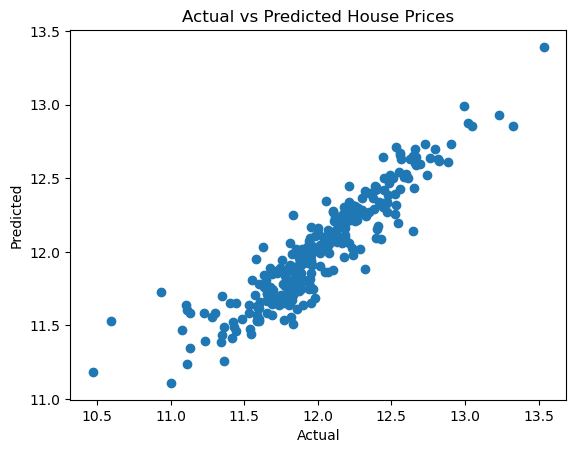

In [30]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual_Predicted House Prices")
plt.savefig(FIG_DIR / "Actual_Predicted_saleprice.png", dpi=300)

out = FIG_DIR / "Actual vs Predicted_saleprice.png"
print("Saved:", out.exists())
print(out)
plt.show()

The scatter plot compares the actual house prices with the predicted values from the model.
Most points lie close to the diagonal trend, indicating that the model predictions align reasonably well with the true values.
Some larger deviations appear at higher price ranges, suggesting that the model may have more difficulty predicting very expensive houses.

In [29]:
coefficients=pd.DataFrame({
    'Feature':features,
    'Coefficient':model.coef_
    
}).sort_values(by='Coefficient', ascending=False)

coefficients

,Feature,Coefficient
0,OverallQual,0.101034
2,GarageCars,0.095873
4,YearBuilt,0.002318
1,GrLivArea,0.000134
3,TotalSF,0.000102


The model coefficients indicate that OverallQual and GarageCars have the strongest positive influence on housing prices, suggesting that house quality and garage capacity are key drivers of property value.

## Conclusion

A baseline linear regression model was built to predict housing prices using key numerical features. The results show that variables such as overall house quality and living area have strong influence on property prices. Future improvements may include incorporating categorical features using one-hot encoding, applying regularized models such as Ridge or Lasso, and exploring more advanced models like Random Forest or XGBoost with cross-validation.